# Reporte de Perfilado de Datos — NovaMarket

Este notebook aplica una rutina de **EDA (Exploratory Data Analysis)** completa al dataset crudo de NovaMarket
(`NovaMarket_datos_crudos.csv`, 620 registros x 14 columnas).

Para cada variable se documenta:
- Tipo de dato
- % de valores faltantes
- Estadísticos descriptivos (numéricas) o frecuencias y cardinalidad (categóricas)

Se incluyen visualizaciones (histograma y boxplot) y se cierra con una lista de **señales de alerta**
sobre la calidad de los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

df = pd.read_csv('NovaMarket_datos_crudos.csv')
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Filas: 620 | Columnas: 14


,id_pedido,id_cliente,fecha_compra,canal,ciudad,codigo_postal,categoria_producto,producto,precio,unidades,edad_cliente,correo,nivel_satisfaccion,fecha_actualizacion_stock
0,P00383,C0276,2026-01-03,App,Bucaramanga,68001,Belleza,Camiseta,-1742611.0,4,-19,c0276gmail.com,alto,2026-07-01
1,P00403,C0167,6/12/2026,Web,Cali,76001,Deportes,Cafetera,1828583.0,2,23,c0167@hotmail.com,MEDIO,2026-07-01
2,P00403,C0167,6/12/2026,Web,Cali,76001,Deportes,Cafetera,1828583.0,2,23,c0167@hotmail.com,MEDIO,2026-07-01
3,P00450,C0128,07/09/2026,App,bucaramanga,68001,electronica,Set bloques,787178.0,6,69,c0128@hotmail.com,MEDIO,2026-07-15
4,P00449,C0304,2025-07-19,Tienda,Bogotá,8001,Belleza,Audífonos BT,357231.0,5,67,c0304@novamarket.co,Bajo,2026-05-20


## 1. Panorama general

Tipos de dato por columna y conteo de no-nulos, según pandas.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_pedido                  620 non-null    str    
 1   id_cliente                 620 non-null    str    
 2   fecha_compra               620 non-null    str    
 3   canal                      620 non-null    str    
 4   ciudad                     589 non-null    str    
 5   codigo_postal              620 non-null    int64  
 6   categoria_producto         620 non-null    str    
 7   producto                   620 non-null    str    
 8   precio                     599 non-null    float64
 9   unidades                   620 non-null    int64  
 10  edad_cliente               620 non-null    int64  
 11  correo                     516 non-null    str    
 12  nivel_satisfaccion         574 non-null    str    
 13  fecha_actualizacion_stock  620 non-null    str    
dtypes: fl

## 2. Perfil por variable

Construimos una tabla resumen con: tipo de dato, cantidad y % de faltantes, y cardinalidad
(número de valores únicos) para **todas** las columnas.

In [3]:
resumen = pd.DataFrame({
    'tipo_dato': df.dtypes.astype(str),
    'faltantes': df.isna().sum(),
    '%_faltantes': (df.isna().mean() * 100).round(2),
    'valores_unicos': df.nunique(),
    '%_cardinalidad': (df.nunique() / len(df) * 100).round(1),
})
resumen

,tipo_dato,faltantes,%_faltantes,valores_unicos,%_cardinalidad
id_pedido,str,0,0.00,600,96.8
id_cliente,str,0,0.00,311,50.2
fecha_compra,str,0,0.00,495,79.8
canal,str,0,0.00,3,0.5
ciudad,str,31,5.00,19,3.1
codigo_postal,int64,0,0.00,6,1.0
categoria_producto,str,0,0.00,17,2.7
producto,str,0,0.00,14,2.3
precio,float64,21,3.39,579,93.4
unidades,int64,0,0.00,12,1.9


### 2.1 Variables numéricas: estadísticos descriptivos

`codigo_postal`, `precio`, `unidades` y `edad_cliente` son numéricas. Se calculan media, desviación
estándar, cuartiles, mínimo/máximo y **skewness** (asimetría) para detectar sesgos y valores extremos.

In [4]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print("Columnas numéricas:", num_cols)

stats_num = df[num_cols].describe().T
stats_num['skew'] = df[num_cols].skew()
stats_num['%_faltantes'] = (df[num_cols].isna().mean() * 100).round(2)
stats_num

Columnas numéricas: ['codigo_postal', 'precio', 'unidades', 'edad_cliente']


,count,mean,std,min,25%,50%,75%,max,skew,%_faltantes
codigo_postal,620.0,3.191713e+04,3.033959e+04,5001.0,8001.0,13001.0,68001.0,76001.0,0.578037,0.00
precio,599.0,4.888703e+06,4.292512e+07,-2448455.0,591402.0,1178666.0,1856670.5,773003787.0,13.899942,3.39
unidades,620.0,1.886823e+02,1.240652e+03,-3.0,2.0,3.0,5.0,9999.0,7.069053,0.00
edad_cliente,620.0,4.801290e+01,2.866851e+01,-20.0,31.0,46.0,63.0,200.0,2.082409,0.00


### 2.2 Variables categóricas / texto: frecuencias y cardinalidad

Para cada variable no numérica se listan sus valores más frecuentes (top 10) y su cardinalidad total.
Esto permite detectar inconsistencias de formato (mayúsculas/minúsculas, tildes, abreviaturas) que
inflan artificialmente el número de categorías "distintas".

In [5]:
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
print("Columnas categóricas / texto:", cat_cols)

for col in cat_cols:
    n_unique = df[col].nunique(dropna=True)
    n_missing = df[col].isna().sum()
    print(f"\n=== {col} | cardinalidad={n_unique} | faltantes={n_missing} ({n_missing/len(df)*100:.1f}%) ===")
    print(df[col].value_counts(dropna=False).head(10))

Columnas categóricas / texto: ['id_pedido', 'id_cliente', 'fecha_compra', 'canal', 'ciudad', 'categoria_producto', 'producto', 'correo', 'nivel_satisfaccion', 'fecha_actualizacion_stock']

=== id_pedido | cardinalidad=600 | faltantes=0 (0.0%) ===
id_pedido
P00403    2
P00416    2
P00397    2
P00335    2
P00343    2
P00207    2
P00201    2
P00457    2
P00463    2
P00263    2
Name: count, dtype: int64

=== id_cliente | cardinalidad=311 | faltantes=0 (0.0%) ===
id_cliente
C0043    6
C0186    5
C0165    5
C0039    5
C0099    5
C0171    5
C0005    5
C0222    5
C0012    5
C0336    5
Name: count, dtype: int64

=== fecha_compra | cardinalidad=495 | faltantes=0 (0.0%) ===
fecha_compra
15/11/2027    9
2027-05-20    8
00/00/2026    8
2026-13-05    6
31/04/2026    5
11/11/2025    4
2025-09-04    4
19/11/2025    3
18/10/2026    3
2026-03-18    3
Name: count, dtype: int64

=== canal | cardinalidad=3 | faltantes=0 (0.0%) ===
canal
Tienda    224
App       218
Web       178
Name: count, dtype: int64

=


=== correo | cardinalidad=429 | faltantes=104 (16.8%) ===
correo
NaN                    104
c0012@hotmail.com        4
c0336@novamarket.co      4
c0165@hotmail.com        3
c0097@hotmail.com        3
c0005@novamarket.co      3
c0145@gmail.com          3
c0197@hotmail.com        3
c0037@hotmail.com        3
c0038@gmail.com          3
Name: count, dtype: int64

=== nivel_satisfaccion | cardinalidad=8 | faltantes=46 (7.4%) ===
nivel_satisfaccion
Alto     91
ALTO     84
Medio    74
bajo     73
medio    70
alto     67
Bajo     62
MEDIO    53
NaN      46
Name: count, dtype: int64

=== fecha_actualizacion_stock | cardinalidad=8 | faltantes=0 (0.0%) ===
fecha_actualizacion_stock
2026-07-15    152
2026-05-20    134
2026-07-01    128
2026-06-10    118
2024-01-15     29
2027-03-01     21
2023-11-30     20
2024-06-01     18
Name: count, dtype: int64


## 3. Duplicados

Revisamos duplicados exactos de fila completa y duplicados de `id_pedido` (que debería ser único por pedido).

In [6]:
print("Filas duplicadas (todas las columnas iguales):", df.duplicated().sum())
print("id_pedido duplicados (registros involucrados):", df.duplicated(subset='id_pedido', keep=False).sum())
df[df.duplicated(subset='id_pedido', keep=False)].sort_values('id_pedido').head(10)

Filas duplicadas (todas las columnas iguales): 20
id_pedido duplicados (registros involucrados): 40


,id_pedido,id_cliente,fecha_compra,canal,ciudad,codigo_postal,categoria_producto,producto,precio,unidades,edad_cliente,correo,nivel_satisfaccion,fecha_actualizacion_stock
380,P00030,C0099,2027-05-20,Web,medellin,5001,juguetes,Set bloques,2084081.0,3,18,NaN,Alto,2026-07-15
240,P00030,C0099,2027-05-20,Web,medellin,5001,juguetes,Set bloques,2084081.0,3,18,NaN,Alto,2026-07-15
554,P00043,C0012,4/11/2025,App,bucaramanga,68001,Belleza,Mancuernas,1249367.0,3,32,c0012@hotmail.com,MEDIO,2026-06-10
308,P00043,C0012,4/11/2025,App,bucaramanga,68001,Belleza,Mancuernas,1249367.0,3,32,c0012@hotmail.com,MEDIO,2026-06-10
585,P00110,C0265,2026-01-23,Tienda,Medellin,5001,Deportes,Smart TV,1579954.0,6,19,c0265@yahoo.com,Medio,2026-07-01
294,P00110,C0265,2026-01-23,Tienda,Medellin,5001,Deportes,Smart TV,1579954.0,6,19,c0265@yahoo.com,Medio,2026-07-01
348,P00116,C0127,2026-06-19,Tienda,bucaramanga,68001,MODA,Smartphone,1138199.0,1,65,c0127@novamarket.co,Medio,2026-07-15
550,P00116,C0127,2026-06-19,Tienda,bucaramanga,68001,MODA,Smartphone,1138199.0,1,65,c0127@novamarket.co,Medio,2026-07-15
561,P00123,C0043,2025-01-08,Web,Bucaramanga,68001,Juguetería,Smart TV,1347930.0,6,59,NaN,Medio,2026-06-10
614,P00123,C0043,2025-01-08,Web,Bucaramanga,68001,Juguetería,Smart TV,1347930.0,6,59,NaN,Medio,2026-06-10


## 4. Visualizaciones

### 4.1 Histograma — distribución de `precio`

La variable `precio` es la más relevante del negocio (valor de cada línea de pedido). El histograma
muestra una distribución con **fuerte sesgo a la derecha** (cola larga por valores extremos).

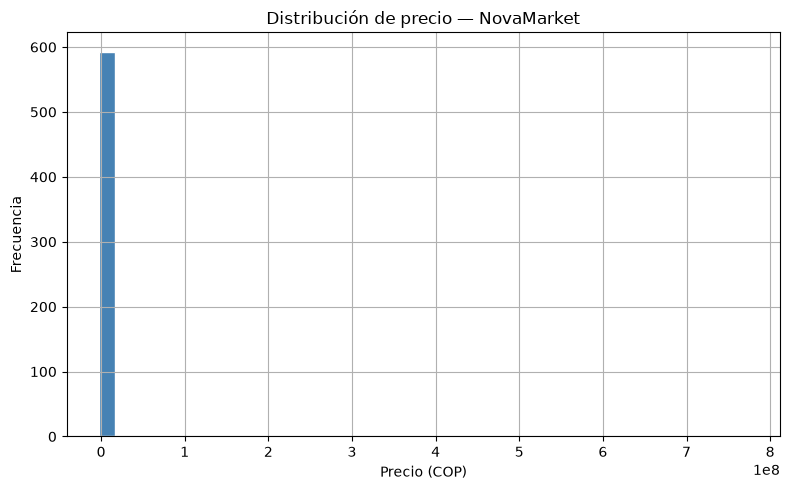

Media: 4,888,703 | Mediana: 1,178,666 | Skew: 13.90


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
df['precio'].hist(bins=40, color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Distribución de precio — NovaMarket')
ax.set_xlabel('Precio (COP)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

print(f"Media: {df['precio'].mean():,.0f} | Mediana: {df['precio'].median():,.0f} | Skew: {df['precio'].skew():.2f}")

### 4.2 Boxplot — variables numéricas

El boxplot conjunto de las variables numéricas evidencia outliers extremos y valores fuera de rango
físicamente imposible (edades negativas o mayores a 100, precios negativos, cantidades absurdas).

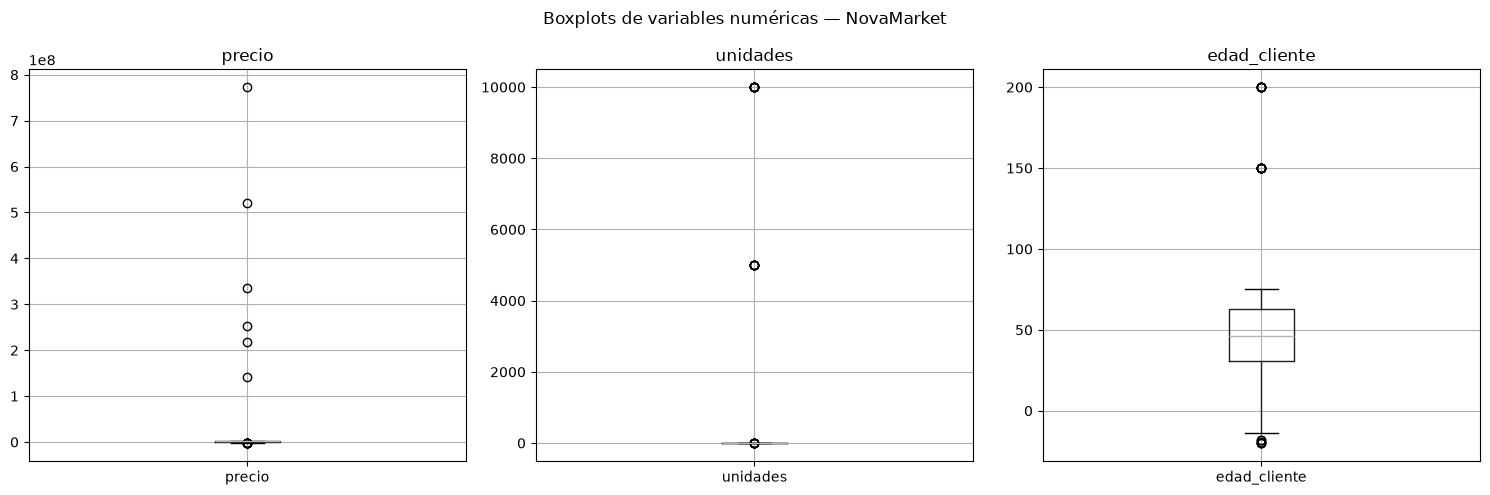

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.boxplot(column='precio', ax=axes[0])
axes[0].set_title('precio')

df.boxplot(column='unidades', ax=axes[1])
axes[1].set_title('unidades')

df.boxplot(column='edad_cliente', ax=axes[2])
axes[2].set_title('edad_cliente')

plt.suptitle('Boxplots de variables numéricas — NovaMarket')
plt.tight_layout()
plt.show()

## 5. Señales de alerta detectadas

A partir del perfilado anterior, se identifican los siguientes problemas de calidad de datos:

1. **Duplicados**: 20 filas están completamente duplicadas (mismo `id_pedido` repetido dos veces cada una,
   40 registros involucrados en total) — deben deduplicarse antes de cualquier análisis.
2. **`precio` con valores imposibles**: 19 registros tienen precio **negativo** y hay valores extremos
   hasta ~773 millones de COP, frente a una mediana de ~1.18 millones. El skewness es ~13.9 (sesgo muy fuerte
   a la derecha), y además tiene 21 faltantes (3.4%).
3. **`unidades` con valores centinela/erróneos**: 14 registros negativos, 8 registros con el valor `9999`
   y 7 con `5000` — valores que parecen códigos de error o placeholders, no cantidades reales de compra.
4. **`edad_cliente` fuera de rango físico**: 15 registros con edad negativa y 17 con edad mayor a 100 años
   (máximo 200) — datos claramente inválidos.
5. **`ciudad` inconsistente**: 19 valores "únicos" para lo que en realidad son ~7 ciudades, por mezcla de
   mayúsculas/minúsculas (`Bucaramanga`, `bucaramanga`, `BUCARAMANGA`), abreviaturas (`B/quilla`) y
   problemas de **codificación de caracteres** (`Bogot�`, `Medell�n`) que corrompen las tildes/eñes.
   Además tiene 31 faltantes (5.0%).
6. **`categoria_producto` inconsistente**: mismo problema — 17 valores únicos que en realidad son ~6
   categorías (`Belleza/belleza`, `Electronica/Electr�nica/ELECTRONICA`, `Jugueteria/Jugueter�a`, etc.),
   también con mojibake en tildes.
7. **`nivel_satisfaccion` inconsistente**: 8 valores únicos para 3 niveles reales (`Alto/ALTO/alto`,
   `Medio/MEDIO/medio`, `Bajo/bajo`), más 46 faltantes (7.4%).
8. **`codigo_postal` no confiable**: una misma ciudad aparece asociada a hasta 6 códigos postales distintos
   (p.ej. "Bucaramanga" con 5 códigos diferentes), lo que sugiere que el campo fue generado o capturado
   incorrectamente y no debe usarse como fuente de verdad geográfica.
9. **`fecha_compra` con formatos mixtos y fechas imposibles**: coexisten formatos `YYYY-MM-DD` y
   `DD/MM/YYYY` en la misma columna; al intentar parsear, 16 valores no son interpretables (p.ej.
   `30/02/2026`, una fecha que no existe). También hay 137 fechas de compra posteriores a hoy (2026-07-28),
   es decir, compras "futuras".
10. **`correo` con formato inválido y muchos faltantes**: 104 faltantes (16.8%) y varios valores sin el
    símbolo `@` (p.ej. `c0276gmail.com`), lo que indica errores de captura o de exportación.
11. **`id_pedido` no es realmente único**: tiene 600 valores distintos sobre 620 filas, confirmando los
    duplicados detectados en la sección 3 — no puede usarse como llave primaria sin antes deduplicar.

Estas señales deben resolverse (limpieza de texto/encoding, parseo de fechas, imputación o eliminación de
valores imposibles, deduplicación) antes de continuar con análisis o modelado sobre este dataset.

## 6. (Opcional) Perfilado automático con `ydata-profiling`

Como complemento, se puede generar un reporte HTML automático con `ydata-profiling`, que calcula de forma
exhaustiva estadísticos, correlaciones, alertas de calidad y distribuciones para todas las variables.
Requiere instalar el paquete (`pip install ydata-profiling`); la celda está protegida con `try/except`
por si no está disponible en el entorno.

In [9]:
try:
    from ydata_profiling import ProfileReport

    profile = ProfileReport(df, title="NovaMarket - Reporte de Perfilado Automático", explorative=True)
    profile.to_file("novamarket_profiling_report.html")
    print("Reporte guardado en novamarket_profiling_report.html")
except ImportError:
    print("ydata-profiling no está instalado. Instálalo con: pip install ydata-profiling")

ydata-profiling no está instalado. Instálalo con: pip install ydata-profiling
